<h1 style="display:flex; align-items:center; line-height:1; margin:0;">
  <img src="rwcircle.png" style="height:36px; width:36px; border-radius:50%; flex-shrink:0;">
  <span style="padding-top:2px; margin-left:10px;"><b>Tinker Scheduling</b>: the case of GJ 3929 b</span>
</h1>

***
**Author**: Nestor Espinoza (nespinoza@stsci.edu) | **Date of last change**: April 17, 2025

## Summary
In this notebook, we perform some simulations that first motivate and then showcase our Tinker Scheduling observability window generator algorithm. This algorithm avoids phase-locking biases (i.e., fixing observing windows to a single phase-constraint) which could lead to missing a large number of events if the orbits of the exoplanets under study turn out to be eccentric. The solution is randomization of those phase-constraints, which have in turn baseline-dependent risks associated with each for ease of selection. We note this notebook assumes posteriors from the time of eclipse and period for the eccentric case are uncorrelated. In general, however, for Tinker Scheduling we create notebooks per target, and the majority of them use the posterior distributions directly instead of the gaussian approxmiation we employ in this notebook.

## Imports
 We will need three simple imports for this notebook:
- *numpy* to handle array functions,
- *matplotlib.pyplot* for plotting data,
- *seaborn* for giving publication-quality style to plots,
- *scipy.ndimage.median_filter* to perform median filtering of some simulations. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')

import matplotlib as mpl 

In [2]:
# And also Arial fonts :-):
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# No top and right edges:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

In [3]:
from scipy.ndimage import median_filter

In [4]:
np.random.seed(127)

## 1. General simulation setup

Let's define a function first that, given a time of eclipse `T_eclipse`, period `P` of the event and eclipse duration `T14`, tells you if an eclipse happens in a given observation starting at `tstart` of length `tbaseline`. The _entire_ eclipse needs to happen in the given observation for this to return `True`:

In [5]:
def is_eclipse(T_eclipse, P, T14, tstart, tbaseline):
    """
    T_eclipse:  Time-of-eclipse center (days).
    P:          Period of the eclipse event (days).
    T14:        Eclipse duration (hours).
    tstart:     Day of start of observations (days)
    tbaseline:  Total duration of the observations (hours).
    """

    phase_start = ( tstart - T_eclipse ) / P                     # Get the phase at the start of the observation.

    # Do checks both on the floor and ceil; former in case baseline is close to the period:
    n_floor = np.floor( phase_start )
    n_ceil = np.ceil( phase_start )

    # Does an eclipse happen during the n_ceil event? (most likely):
    t_event = T_eclipse + P * n_ceil
    min_t_event = t_event - ( T14 * 0.5 ) / 24.
    max_t_event = t_event + ( T14 * 0.5 ) / 24.

    if ( min_t_event > tstart ) and ( max_t_event < tstart + tbaseline / 24. ):

        return True

    # Does it happen during n_floor?
    t_event = T_eclipse + P * n_floor
    min_t_event = t_event - ( T14 * 0.5 ) / 24.
    max_t_event = t_event + ( T14 * 0.5 ) / 24.   

    if ( min_t_event > tstart ) and ( max_t_event < tstart + tbaseline / 24. ):

        return True
    
    # If not, bad luck, didn't happen:
    return False

Let's also make a figure that gives back times and fluxes of the eclipse event:

In [6]:
def get_phases(t, P, t0, phmin=0.5):
    """
    Given input times, a period (or posterior dist of periods)
    and time of transit center (or posterior), returns the
    phase at each time t.
    """
    if type(t) is not float:

        phase = ( (t - np.median(t0)) / np.median(P) ) % 1
        ii = np.where(phase >= phmin)[0]
        phase[ii] = phase[ii] - 1.0
      
    else:
      
        phase = ((t - np.median(t0)) / np.median(P)) % 1
        
        if phase >= 0.5:
            phase = phase - 1.0
            
    return phase

def generate_eclipse(T_eclipse, P, T14, tstart, tbaseline, depth = 100, npoints = 1000):

    """
    T_eclipse:  Time-of-eclipse center (days).
    P:          Period of the eclipse event (days).
    T14:        Eclipse duration (hours).
    tstart:     Day of start of observations (days)
    tbaseline:  Total duration of the observations (hours).

    Optional:

    depth:      Eclipse depth (ppm).
    npoints:    Number of datapoints to evaluate eclipse.
    """    

    # Generate time baseline directly:
    ts = np.linspace( tstart, tstart + ( tbaseline / 24. ), npoints )
    fs = np.ones( npoints )

    # Get phases of eclipse happening:
    ps = get_phases(ts, P, T_eclipse)
    idx = np.where( np.abs(ps) * P < (T14 * 0.5) / 24.  )[0]

    # Replace fluxes where eclipse happens:
    fs[idx] = 1. - depth * 1e-6

    return ts, fs

Let's check this works. Let's define some eclipse event properties first:

In [7]:
T_eclipse = 2447069.5 # A random date
P = 365. # A random period
T14 = 1. # A random eclipse duration (hours)

Set some (also very random) baseline properties:

In [8]:
# Define observation start and baseline:
tstart = 2458019.375
tbaseline = 10.

By eye, we should see the event, because:

In [9]:
( tstart - T_eclipse ) / P

29.999657534246577

i.e., we are 

In [10]:
phase = ( tstart - T_eclipse ) / P

print( ( np.ceil(phase) - phase ) * P * 24., 'hours' )

2.999999999987466 hours


Away from mid-event. Indeed, let's plot the event:

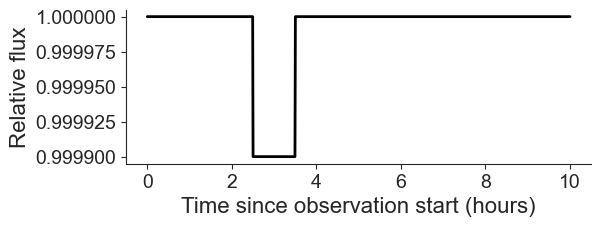

In [11]:
# Plot event:
t, f = generate_eclipse(T_eclipse, P, T14, tstart, tbaseline)

plt.figure( figsize=(6, 2) )

plt.plot( ( t - t[0] ) * 24., f , '-', lw = 2, color = 'black')

plt.ticklabel_format(useOffset=False)

plt.xlabel('Time since observation start (hours)', fontsize = 16)
plt.ylabel('Relative flux', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

Great! 3 hours after start, as expected from our calculation. What does our eclipse detection function say?

In [12]:
is_eclipse(T_eclipse, P, T14, tstart, tbaseline)

True

Yay! Now let's get a partial eclipse:

In [13]:
# Define observation start and baseline:
tstart = 2458019.375 + (3./24.)
tbaseline = 10.

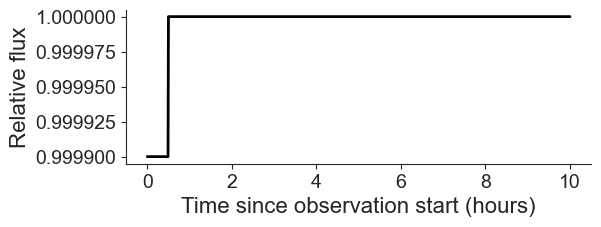

In [14]:
# Plot event:
t, f = generate_eclipse(T_eclipse, P, T14, tstart, tbaseline)

plt.figure( figsize=(6, 2) )

plt.plot( ( t - t[0] ) * 24., f , '-', lw = 2, color = 'black')

plt.ticklabel_format(useOffset=False)

plt.xlabel('Time since observation start (hours)', fontsize = 16)
plt.ylabel('Relative flux', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

Our function then says:

In [15]:
is_eclipse(T_eclipse, P, T14, tstart, tbaseline)

False

Perfect. Let's run some experiments now.

## 2. Experiment 1: baseline --- "one or the other" easy observation

### 2.1 Eclipse is, indeed, circular

Let's test first the easy case: the eclipse is indeed circular, with some uncertainty. We schedule with plenty of time around --- do we get back detections?

In [16]:
# Properties for the circular case fit:
t0_eclipse_circular = 2460789.089826044 # days
t0_eclipse_circular_error = 0.0015547705084725846 # days
P_circular = 2.6162644059
P_circular_error = 0.0000023101
T14_circular = 69.96503230352143 / 60. # eclipse duration in hours

In [17]:
# Define observation details: number of eclipses to schedule:
neclipses = 4
# length of baseline:
tbaseline = 5.

All right --- with these parameters, let's simulate 100 draws from the eclipse times, and see if we detect the eclipses every time with this baseline:

In [18]:
nsimulation = 1000

In [19]:
# Draw nsimulation t0s:
t0s = np.random.normal(t0_eclipse_circular, t0_eclipse_circular_error, nsimulation)
# Same for P:
Ps = np.random.normal(P_circular, P_circular_error, nsimulation)
# Successes per simulation:
nsuccesses = np.zeros(nsimulation)

for i in range(nsimulation):

    trials = np.zeros(neclipses)
    for j in range(neclipses):

        tstart = t0_eclipse_circular + P_circular * j - (tbaseline/2.) / 24.
        trials[j] = is_eclipse(t0s[i], Ps[i], T14_circular, tstart, tbaseline)
    nsuccesses[i] = np.sum(trials)

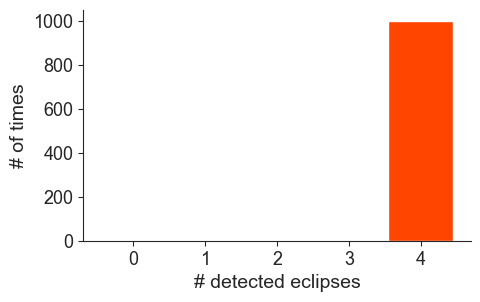

In [20]:
plt.figure(figsize = (5, 3))
plt.hist(nsuccesses, bins = np.arange(-0.5, neclipses + 1.5, 1), rwidth=0.9, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('# of times', fontsize = 14)
plt.show()

Makes sense! We detect all eclipses for all the simulations.

### 2.2 Eclipse is, indeed, eccentric --- but we schedule circular

Let's do the worst case scenario. We now schedule _believing_ it is circular, but it is indeed an eccentric orbit. How would our rate of success change?

In [21]:
# Properties for the eccentric case fit:
t0_eclipse_eccentric = 2460789.0060092243 # days
t0_eclipse_eccentric_error = 0.04642433709846186 # days
P_eccentric = 2.6162643243
P_eccentric_error = 0.0000024869
T14_eccentric = 65.71901210220913 / 60. # eclipse duration in hours

In [22]:
# Draw nsimulation t0s:
t0s = np.random.normal(t0_eclipse_eccentric, t0_eclipse_eccentric_error, nsimulation)
# Same for P:
Ps = np.random.normal(P_eccentric, P_eccentric_error, nsimulation)
# Successes per simulation:
nsuccesses = np.zeros(nsimulation)

for i in range(nsimulation):

    trials = np.zeros(neclipses)
    for j in range(neclipses):

        # Schedule using circular parameters:
        tstart = t0_eclipse_circular + P_circular * j - (tbaseline/2.) / 24.
        trials[j] = is_eclipse(t0s[i], Ps[i], T14_eccentric, tstart, tbaseline)
    nsuccesses[i] = np.sum(trials)

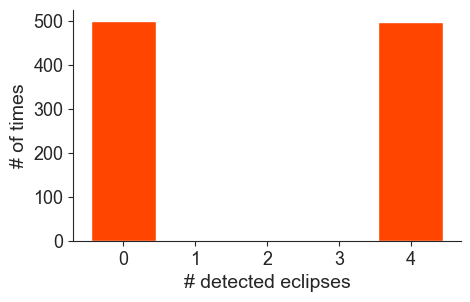

In [23]:
plt.figure(figsize = (5, 3))
plt.hist(nsuccesses, bins = np.arange(-0.5, neclipses + 1.5, 1), rwidth=0.9, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('# of times', fontsize = 14)
plt.show()

Ouch! Now we miss _all_ the eclipses about 50% of the time. What if we repeat the same experiment, but increase the baseline --- say, we double it:

In [24]:
# length of baseline:
tbaseline = 10.

In [25]:
# Draw nsimulation t0s:
t0s = np.random.normal(t0_eclipse_eccentric, t0_eclipse_eccentric_error, nsimulation)
# Same for P:
Ps = np.random.normal(P_eccentric, P_eccentric_error, nsimulation)
# Successes per simulation:
nsuccesses = np.zeros(nsimulation)

for i in range(nsimulation):

    trials = np.zeros(neclipses)
    for j in range(neclipses):

        # Schedule using circular parameters:
        tstart = t0_eclipse_circular + P_circular * j - (tbaseline/2.) / 24.
        trials[j] = is_eclipse(t0s[i], Ps[i], T14_eccentric, tstart, tbaseline)
    nsuccesses[i] = np.sum(trials)

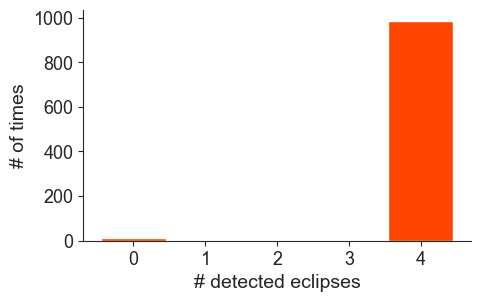

In [26]:
plt.figure(figsize = (5, 3))
plt.hist(nsuccesses, bins = np.arange(-0.5, neclipses + 1.5, 1), rwidth=0.9, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('# of times', fontsize = 14)
plt.show()

Nice! If we double it, then on 100 simulations we detect all eclipses...

In [27]:
print( len(np.where(nsuccesses == neclipses)[0]),'out of',nsimulation)

986 out of 1000


times. There's still some trials in which we miss _all_ the eclipses (!); this would be total failure for our team. 

### 2.3 Eclipse is, indeed, eccentric --- we schedule eccentric

What if we scheduled with the eccentric parameters with the original baseline?

In [28]:
tbaseline = 5.

In [29]:
# Draw nsimulation t0s:
t0s = np.random.normal(t0_eclipse_eccentric, t0_eclipse_eccentric_error, nsimulation)
# Same for P:
Ps = np.random.normal(P_eccentric, P_eccentric_error, nsimulation)
# Successes per simulation:
nsuccesses = np.zeros(nsimulation)

for i in range(nsimulation):

    trials = np.zeros(neclipses)
    for j in range(neclipses):

        # Schedule using circular parameters:
        tstart = t0_eclipse_eccentric + P_eccentric * j - (tbaseline/2.) / 24.
        trials[j] = is_eclipse(t0s[i], Ps[i], T14_eccentric, tstart, tbaseline)
    nsuccesses[i] = np.sum(trials)

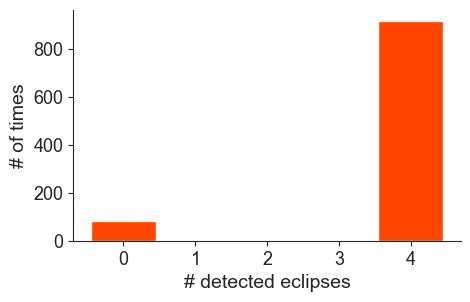

In [30]:
plt.figure(figsize = (5, 3))
plt.hist(nsuccesses, bins = np.arange(-0.5, neclipses + 1.5, 1), rwidth=0.9, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('# of times', fontsize = 14)
plt.show()

Now detectability goes up --- still a fraction of times we don't detect _any_ eclipse:

In [31]:
print( len(np.where(nsuccesses == neclipses)[0]),'out of',nsimulation)

917 out of 1000


But, overall, much better.

### 2.4 Exploring baseline times for detectability

Let's see how changing the baseline time changes our chances of detecting the eclipses. To this end, first, pack the experiment of scheduling an eccentric orbit believeing its circular:

In [32]:
def eccentric_experiment1(tbaseline, success_number):

    # Draw nsimulation t0s:
    t0s = np.random.normal(t0_eclipse_eccentric, t0_eclipse_eccentric_error, nsimulation)
    # Same for P:
    Ps = np.random.normal(P_eccentric, P_eccentric_error, nsimulation)
    # Successes per simulation:
    nsuccesses = np.zeros(nsimulation)
    
    for i in range(nsimulation):
    
        trials = np.zeros(neclipses)
        for j in range(neclipses):
    
            # Schedule using circular parameters:
            tstart = t0_eclipse_circular + P_circular * j - (tbaseline/2.) / 24.
            trials[j] = is_eclipse(t0s[i], Ps[i], T14_eccentric, tstart, tbaseline)
        nsuccesses[i] = np.sum(trials)

    return float( len(np.where(nsuccesses == success_number)[0]) ) / nsimulation

And now let's run it over a range of baselines:

In [33]:
tbaselines = np.linspace(3,15,100)
detectability = np.zeros(len(tbaselines))

In [34]:
for k in range( len(tbaselines) ):

    detectability[k] = eccentric_experiment1(tbaselines[k], success_number = neclipses)

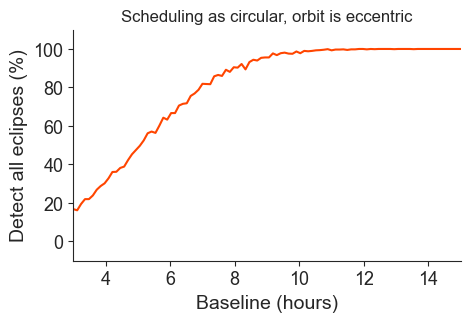

In [35]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability * 100, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Scheduling as circular, orbit is eccentric')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.show()

So --- if we set a ~10-hour baseline, we are almost guaranteed to see all the eclipses even if we schedule assuming the orbit is circular. What's the analogous if we measure the fraction of times we miss _all_ eclipses?

In [36]:
non_detectability = np.zeros(len(tbaselines))
for k in range( len(tbaselines) ):

    non_detectability[k] = eccentric_experiment1(tbaselines[k], success_number = 0)

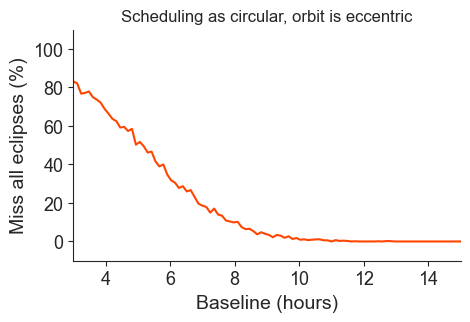

In [37]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability * 100, '-', color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Scheduling as circular, orbit is eccentric')
plt.show()

What happens if we repeat the experiment, but we schedule with the mean parameters of the eccentric orbit? Let's pack _that_ experiment:

In [38]:
def eccentric_experiment2(tbaseline, success_number):

    # Draw nsimulation t0s:
    t0s = np.random.normal(t0_eclipse_eccentric, t0_eclipse_eccentric_error, nsimulation)
    # Same for P:
    Ps = np.random.normal(P_eccentric, P_eccentric_error, nsimulation)
    # Successes per simulation:
    nsuccesses = np.zeros(nsimulation)
    
    for i in range(nsimulation):
    
        trials = np.zeros(neclipses)
        for j in range(neclipses):
    
            # Schedule using circular parameters:
            tstart = t0_eclipse_eccentric + P_eccentric * j - (tbaseline/2.) / 24.
            trials[j] = is_eclipse(t0s[i], Ps[i], T14_eccentric, tstart, tbaseline)
        nsuccesses[i] = np.sum(trials)

    return float( len(np.where(nsuccesses == success_number)[0]) ) / nsimulation

In [39]:
tbaselines2 = np.linspace(3,15,100)
detectability2 = np.zeros(len(tbaselines2))

In [40]:
for k in range( len(tbaselines2) ):

    detectability2[k] = eccentric_experiment2(tbaselines2[k], success_number = neclipses)

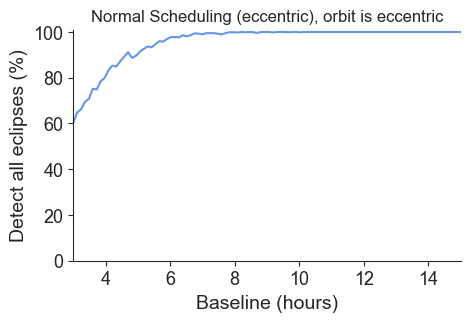

In [41]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines2, detectability2 * 100, color = 'cornflowerblue')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Normal Scheduling (eccentric), orbit is eccentric')
plt.ylim(0,101)
plt.show()

Run again for missing all eclipses:

In [42]:
non_detectability2 = np.zeros(len(tbaselines2))
for k in range( len(tbaselines2) ):

    non_detectability2[k] = eccentric_experiment2(tbaselines2[k], success_number = 0)

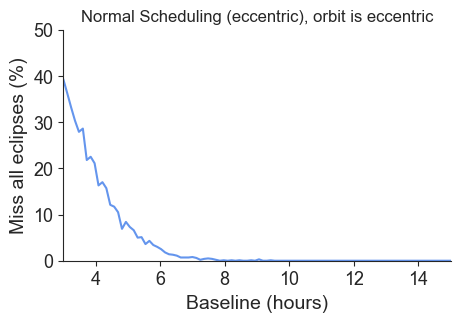

In [43]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines2, non_detectability2 * 100, color = 'cornflowerblue')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Normal Scheduling (eccentric), orbit is eccentric')
plt.ylim(0,50)
plt.show()

Ah! In this case, you still might miss a bunch of eclipses (because eclipse is uncertain), but your minimum baseline to reach about 100% detectability of the eclipses is much lower --- of order 7 hours. Let's plot both at the same time to see all this in one plot:

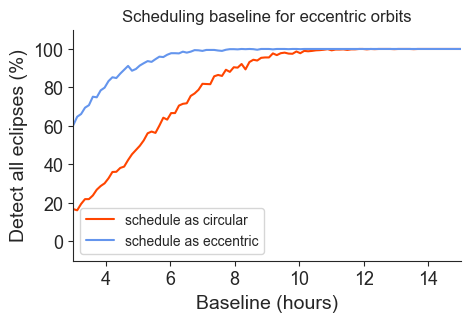

In [44]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability * 100, color = 'orangered', label = 'schedule as circular')
plt.plot(tbaselines2, detectability2 * 100, color = 'cornflowerblue', label = 'schedule as eccentric')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Scheduling baseline for eccentric orbits')
plt.legend()
plt.show()

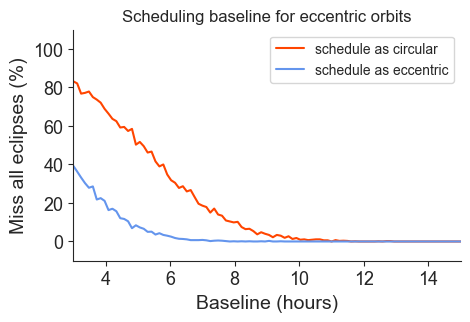

In [45]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability * 100, color = 'orangered', label = 'schedule as circular')
plt.plot(tbaselines2, non_detectability2 * 100, color = 'cornflowerblue', label = 'schedule as eccentric')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Scheduling baseline for eccentric orbits')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.legend()
plt.show()

Problem is, of course, the inverse is also true --- if you schedule as circular or eccentric when the orbit is actually circular, you get into trouble. And because the circular orbit parameters are known so well --- you get into _substantial_ trouble if your baseline is too small:

In [46]:
def circular_experiment1(tbaseline, success_number):

    # Draw nsimulation t0s:
    t0s = np.random.normal(t0_eclipse_circular, t0_eclipse_circular_error, nsimulation)
    # Same for P:
    Ps = np.random.normal(P_circular, P_circular_error, nsimulation)
    # Successes per simulation:
    nsuccesses = np.zeros(nsimulation)
    
    for i in range(nsimulation):
    
        trials = np.zeros(neclipses)
        for j in range(neclipses):
    
            # Schedule using circular parameters:
            tstart = t0_eclipse_eccentric + P_eccentric * j - (tbaseline/2.) / 24.
            trials[j] = is_eclipse(t0s[i], Ps[i], T14_circular, tstart, tbaseline)
        nsuccesses[i] = np.sum(trials)

    return float( len(np.where(nsuccesses == success_number)[0]) ) / nsimulation

In [47]:
tbaselines3 = np.linspace(3,15,100)
detectability3 = np.zeros(len(tbaselines3))

In [48]:
for k in range( len(tbaselines3) ):

    detectability3[k] = circular_experiment1(tbaselines3[k], success_number = neclipses)

In [49]:
non_detectability3 = np.zeros(len(tbaselines3))
for k in range( len(tbaselines3) ):

    non_detectability3[k] = circular_experiment1(tbaselines3[k], success_number = 0)

In [50]:
def circular_experiment2(tbaseline, success_number):

    # Draw nsimulation t0s:
    t0s = np.random.normal(t0_eclipse_circular, t0_eclipse_circular_error, nsimulation)
    # Same for P:
    Ps = np.random.normal(P_circular, P_circular_error, nsimulation)
    # Successes per simulation:
    nsuccesses = np.zeros(nsimulation)
    
    for i in range(nsimulation):
    
        trials = np.zeros(neclipses)
        for j in range(neclipses):
    
            # Schedule using circular parameters:
            tstart = t0_eclipse_circular + P_circular * j - (tbaseline/2.) / 24.
            trials[j] = is_eclipse(t0s[i], Ps[i], T14_circular, tstart, tbaseline)
        nsuccesses[i] = np.sum(trials)

    return float( len(np.where(nsuccesses == success_number)[0]) ) / nsimulation

In [51]:
tbaselines4 = np.linspace(3,15,100)
detectability4 = np.zeros(len(tbaselines4))

In [52]:
for k in range( len(tbaselines4) ):

    detectability4[k] = circular_experiment2(tbaselines4[k], success_number = neclipses)

In [53]:
non_detectability4 = np.zeros(len(tbaselines4))
for k in range( len(tbaselines4) ):

    non_detectability4[k] = circular_experiment2(tbaselines4[k], success_number = 0)

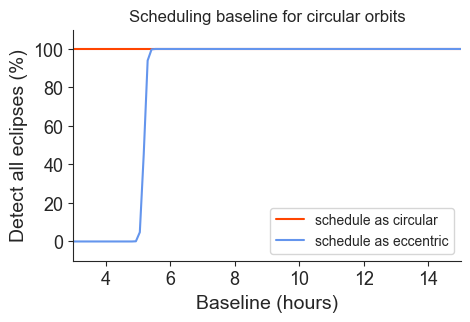

In [54]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines4, detectability4 * 100, color = 'orangered', label = 'schedule as circular')
plt.plot(tbaselines3, detectability3 * 100, color = 'cornflowerblue', label = 'schedule as eccentric')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Scheduling baseline for circular orbits')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.legend()
plt.show()

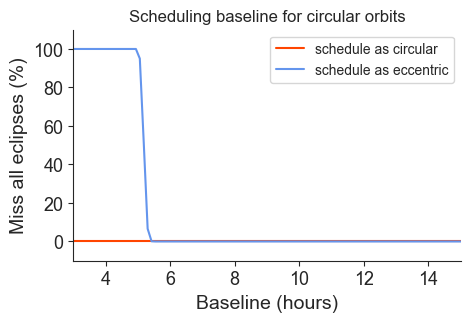

In [55]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines4, non_detectability4 * 100, color = 'orangered', label = 'schedule as circular')
plt.plot(tbaselines3, non_detectability3 * 100, color = 'cornflowerblue', label = 'schedule as eccentric')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Scheduling baseline for circular orbits')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.legend()
plt.show()

This is stating the fact that, if the orbit is truly circular and you schedule as eccentric, because the eccentric orbit is about

In [56]:
print( round( (t0_eclipse_circular - t0_eclipse_eccentric ) * 24., 2), 'hours')

2.01 hours


offset, then scheduling as eccentric with too small of a baseline (< 5 hours) makes you actually miss the eclipse in all your trials! 

Let's do all the plots once again to summarize:

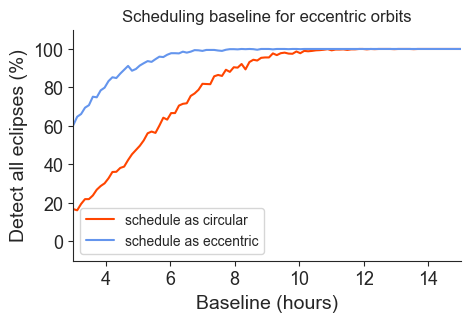

In [57]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability * 100, color = 'orangered', label = 'schedule as circular')
plt.plot(tbaselines2, detectability2 * 100, color = 'cornflowerblue', label = 'schedule as eccentric')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Scheduling baseline for eccentric orbits')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.legend()
plt.show()

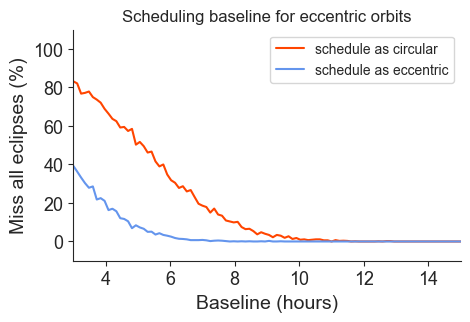

In [58]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability * 100, color = 'orangered', label = 'schedule as circular')
plt.plot(tbaselines2, non_detectability2 * 100, color = 'cornflowerblue', label = 'schedule as eccentric')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Scheduling baseline for eccentric orbits')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.legend()
plt.show()

**If one wanted to be _completely_ risk adverse, where risk means having almost zero chance of missing _all_ the eclipses, you would need to go for a baseline of about 6-7 hours with the eccentric solution parameters**, because:

- If it is actually circular, your chances of missing all the eclipses are basically 0.
- In this same case, your chances of getting all 5 eclipses are virtually 100%.
- If orbit is indeed eccentric (blue line above), chances of missing all eclipses is virtually 0.
- In this same case, chances of getting all the eclipses is about 100%.

The problem, of course, is that this is a non-negligible cost. In practice, because you want to remove the first ~hour beause of the ramp, this is a total cost per eclipse of (6-7)+1 --- (7-8) hours. Times $n$ eclipses is a total cost of $n \times (7-8)$ hours. For $n=4$, this is 28-32 hours, which is of order 7-8% of the DDT if you consider overheads. Is there a better way? Let's try another way... 

## 3. Experiment 2: tinker scheduling

The problem with the experiments above is that, because one "marries" oneself with a solution and fixes the parameters from the beggining, this is "a total hit or total miss" for time baselines under 6-7 hours. One way to circumvent this is to randomize the scheduling; "tinker scheduling" as we call it from now on--- which trades noise in the "full success" case (i.e., getting all the eclipses) for less risk of having a disastrous outcome (i.e., missing all the eclipses). 

In tinker scheduling, instead of fixing the times at which you observe your eclipse, you randomize it instead --- hoping you'll get _at least_ a few eclipses in your windows because of this randomization. Let's repeat the experiments above in this case.

### 3.1 Using eccentric eclipse uncertainties as the randomization parameters

Let's re-run the experiments above using this tinker scheduling technique randomizing the t0's and P's we'll use on each scheduling by using the eclipse uncertainty on the eccentric orbit solution:

In [59]:
def eccentric_lucky_experiment(tbaseline, 
                               true_t0, true_t0_error, 
                               true_P, true_P_error,
                               t0_mean, t0_sigma, 
                               P_mean, P_sigma,
                               success_number):

    # Draw nsimulation t0s:
    t0s = np.random.normal(true_t0, true_t0_error, nsimulation)
    # Same for P:
    Ps = np.random.normal(true_P, true_P_error, nsimulation)
    # Successes per simulation:
    nsuccesses = np.zeros(nsimulation)
    
    for i in range(nsimulation):
    
        trials = np.zeros(neclipses)
        for j in range(neclipses):
    
            # Schedule via lucky scheduling:
            t0 = np.random.normal(t0_mean, t0_sigma)
            P = np.random.normal(P_mean, P_sigma)
            tstart = t0 + P * j - (tbaseline/2.) / 24.
            trials[j] = is_eclipse(t0s[i], Ps[i], T14_eccentric, tstart, tbaseline)
        nsuccesses[i] = np.sum(trials)

    return float( len(np.where(nsuccesses == success_number)[0]) ) / nsimulation

Let's first try the eccentric experiment: we draw the simulation from the t0 and P from the eccentric orbit, and we use those very same parameters as our tinker scheduling randomization parameters:

In [60]:
detectability_ls_ecc_ecc = np.zeros( len(tbaselines) )
non_detectability_ls_ecc_ecc = np.zeros( len(tbaselines) )

for k in range( len(tbaselines) ):

    detectability_ls_ecc_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error, 
                                                             success_number = neclipses)

    non_detectability_ls_ecc_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             success_number = 0)

Let's see how this looks like:

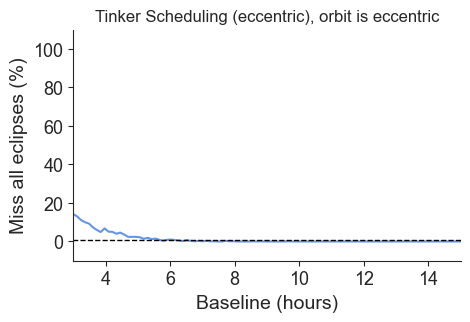

In [61]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_ecc_ecc * 100, color = 'cornflowerblue')
plt.plot([0,np.max(tbaselines)],[1,1], 'k--', lw = 1)
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Tinker Scheduling (eccentric), orbit is eccentric')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.show()

Close-up:

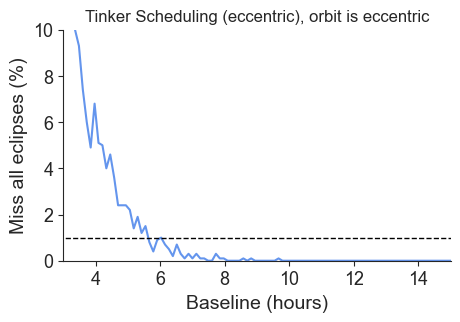

In [62]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_ecc_ecc * 100, color = 'cornflowerblue')
plt.plot([0,np.max(tbaselines)],[1,1], 'k--', lw = 1)
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Tinker Scheduling (eccentric), orbit is eccentric')
plt.ylim(0,10)
plt.show()

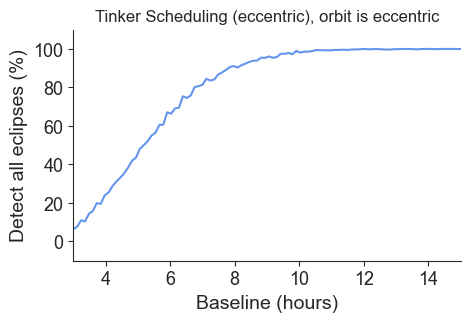

In [63]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_ecc_ecc * 100, color = 'cornflowerblue')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Tinker Scheduling (eccentric), orbit is eccentric')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines),np.max(tbaselines))
plt.show()

All right, this makes sense. Now we can do a baseline of ~5 hours and we get a ~1% chance of missing all the eccentric events (before that was about 10%!). However, we have traded success: on a 5 hour baseline, if the orbit is eccentric, the chances of detecting all the eclipses are only 30%.  

What are the chances of detecting $n$-eclipses at this 5-hour baseline mark?

In [64]:
n_eclipses = np.arange(0, neclipses + 1)
rate = np.zeros(len(n_eclipses))

for i in range(len(n_eclipses)):
    
    rate[i] = eccentric_lucky_experiment(5., 
                                         t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                         P_eccentric, P_eccentric_error,
                                         t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                         P_eccentric, P_eccentric_error,
                                         success_number = n_eclipses[i])


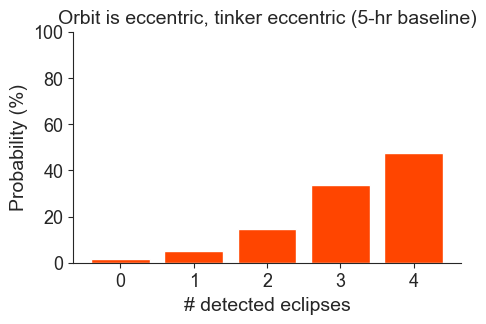

In [65]:
plt.figure(figsize = (5, 3))
plt.bar(n_eclipses, rate*100, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.title('Orbit is eccentric, tinker eccentric (5-hr baseline)', fontsize = 14)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('Probability (%)', fontsize = 14)
plt.ylim(0,100)
plt.show()

Note this is, within the errors of the simulation, a probability mass function as this is the full sample space. This means, for instance, that the probability of getting 3 eclipses or more with this setup is:

In [66]:
print(np.round(np.sum(rate[3:]*100),2), '% probability')

81.1 % probability


So, almost 80% success of having 3 eclipses or more. What if we use a 4-hour baseline?

In [67]:
n_eclipses = np.arange(0, neclipses+1)
rate = np.zeros(len(n_eclipses))

for i in range(len(n_eclipses)):
    
    rate[i] = eccentric_lucky_experiment(4., 
                                         t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                         P_eccentric, P_eccentric_error,
                                         t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                         P_eccentric, P_eccentric_error,
                                         success_number = n_eclipses[i])


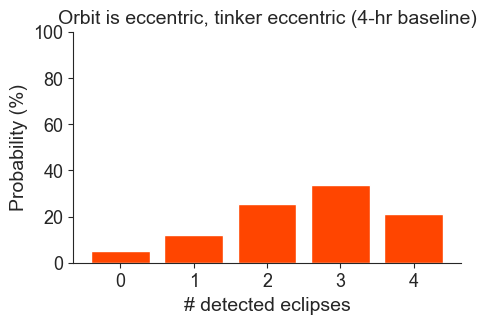

In [68]:
plt.figure(figsize = (5, 3))
plt.bar(n_eclipses, rate*100, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.title('Orbit is eccentric, tinker eccentric (4-hr baseline)', fontsize = 14)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('Probability (%)', fontsize = 14)

plt.ylim(0,100)
plt.show()

Quite a bit worse --- but what about the cummulative of getting 3 eclipses or more with this setup?

In [69]:
print(np.round(np.sum(rate[3:]*100),2), '% probability')

55.0 % probability


So about 60% success of having 3 or more detected.

There's one little problem with this strategy, however. Let's try the same experiment, but now suppose the orbit is circular: 

In [70]:
detectability_ls_circ_ecc = np.zeros( len(tbaselines) )
non_detectability_ls_circ_ecc = np.zeros( len(tbaselines) )

for k in range( len(tbaselines) ):

    detectability_ls_circ_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_circular, t0_eclipse_circular_error,
                                                             P_circular, P_circular_error,
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error, 
                                                             success_number = neclipses)

    non_detectability_ls_circ_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_circular, t0_eclipse_circular_error,
                                                             P_circular, P_circular_error,
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             success_number = 0)

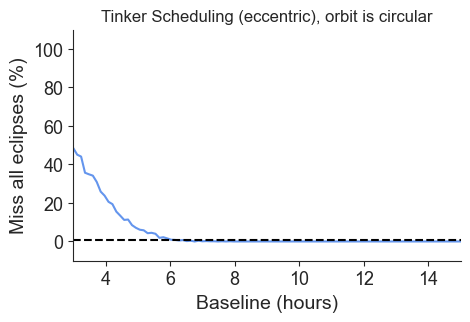

In [71]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_circ_ecc * 100, color = 'cornflowerblue')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Tinker Scheduling (eccentric), orbit is circular')
plt.plot([np.min(tbaselines), np.max(tbaselines)], [1,1], 'k--')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines), np.max(tbaselines))
plt.show()

Close-up:

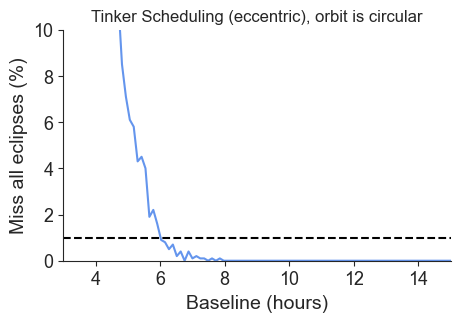

In [72]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_circ_ecc * 100, color = 'cornflowerblue')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Tinker Scheduling (eccentric), orbit is circular')
plt.plot([np.min(tbaselines), np.max(tbaselines)], [1,1], 'k--')
plt.ylim(-0,10)
plt.xlim(np.min(tbaselines), np.max(tbaselines))
plt.show()

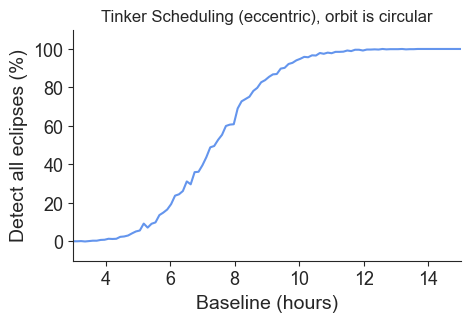

In [73]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_circ_ecc * 100, color = 'cornflowerblue')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Tinker Scheduling (eccentric), orbit is circular')
plt.ylim(-10,110)
plt.xlim(np.min(tbaselines), np.max(tbaselines))
plt.show()

At the 5-hour baseline mark, if the orbit turns out to be circular, there's now about a 3% chance of failure (i.e., you miss all the eclipses). Let's repeat the success histogram we did above for the circular cae:

In [74]:
rate_circular = np.zeros(len(n_eclipses))

for i in range(len(n_eclipses)):
    
    rate_circular[i] = eccentric_lucky_experiment(5., 
                                                  t0_eclipse_circular, t0_eclipse_circular_error,
                                                  P_circular, P_circular_error,
                                                  t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                  P_eccentric, P_eccentric_error, 
                                                  success_number = n_eclipses[i])


Text(0, 0.5, 'Probability (%)')

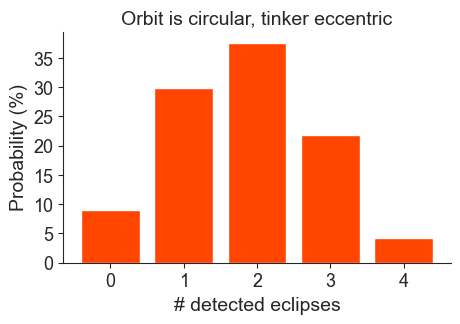

In [75]:
plt.figure(figsize = (5, 3))
plt.bar(n_eclipses, rate_circular*100, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.title('Orbit is circular, tinker eccentric', fontsize = 14)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('Probability (%)', fontsize = 14)

This is very interesting. In this case, the maximum probability is around detecting 2 eclipses. Detecting them all or missing them all has very little chance in this case.

Let's plot these experiments together with the ones we did in the previous sections, as a form of a summary:

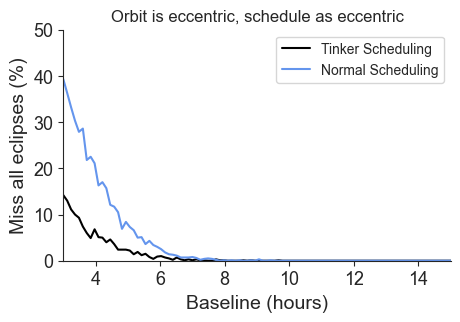

In [76]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_ecc_ecc * 100, color = 'black', label = 'Tinker Scheduling')
plt.plot(tbaselines2, non_detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric')
plt.legend()
plt.ylim(0,50)
plt.show()

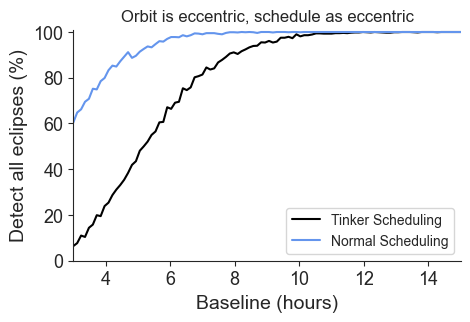

In [77]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_ecc_ecc * 100, color = 'black', label = 'Tinker Scheduling')
plt.plot(tbaselines2, detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric')
plt.legend()
plt.ylim(0,101)
plt.show()

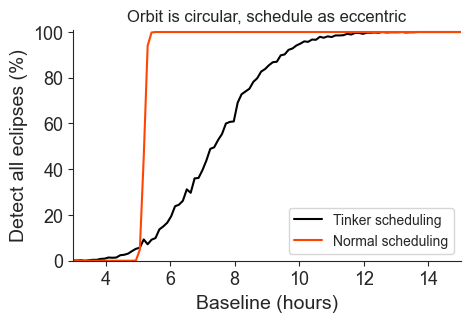

In [78]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_circ_ecc * 100, color = 'black', label = 'Tinker scheduling')
plt.plot(tbaselines3, detectability3 * 100, color = 'orangered', label = 'Normal scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Orbit is circular, schedule as eccentric')
plt.legend()
plt.ylim(0,101)
plt.show()

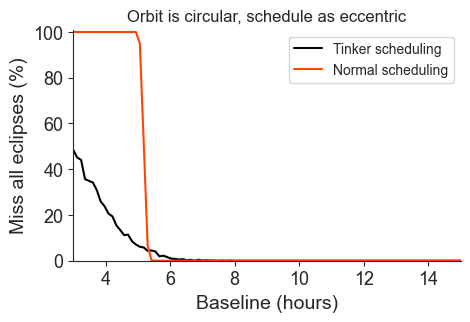

In [79]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_circ_ecc * 100, color = 'black', label = 'Tinker scheduling')
plt.plot(tbaselines3, non_detectability3 * 100, color = 'orangered', label = 'Normal scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Orbit is circular, schedule as eccentric')
plt.legend()
plt.ylim(0,101)
plt.show()

It seems in this case, you can safely get away with 5-6 hours baseline if you apply tinker scheduling --- chances of missing all eclipses in this case is almost zero, if you want to be full risk adverse. The problem, however, is that the chances of detecting all the eclipses really suffers --- if you schedule as eccentric, and the orbit turns out to be circular, with tinker scheduling you will very likely _not_ have all the eclipses --- in fact, is very unlikely you will get them all!

One could ask: does the parameters one define for tinker scheduling matter? Let's study it next.

### 3.2 Using eccentric eclipse uncertainties as the randomization parameters --- but the mean between the circular-ecc t0's

In [80]:
detectability_ls_ecc_ecc = np.zeros( len(tbaselines) )
non_detectability_ls_ecc_ecc = np.zeros( len(tbaselines) )

t0_effective = ( t0_eclipse_circular + t0_eclipse_eccentric ) * 0.5

for k in range( len(tbaselines) ):

    detectability_ls_ecc_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             t0_effective, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error, 
                                                             success_number = neclipses)

    non_detectability_ls_ecc_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             t0_effective, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             success_number = 0)

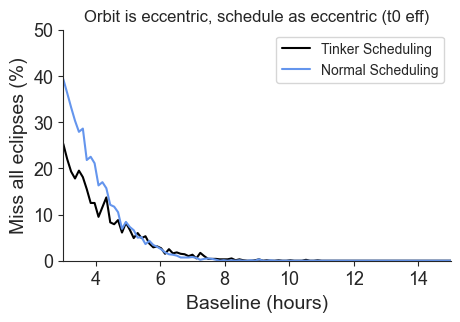

In [81]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_ecc_ecc * 100, color = 'black', label = 'Tinker Scheduling')
plt.plot(tbaselines2, non_detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric (t0 eff)')
plt.legend()
plt.ylim(0,50)
plt.show()

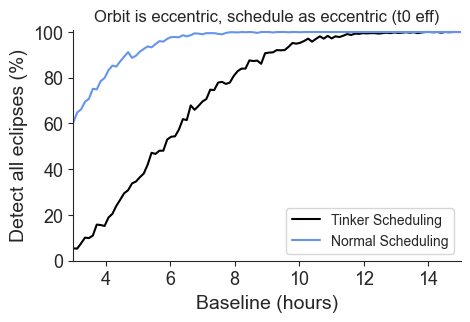

In [82]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_ecc_ecc * 100, color = 'black', label = 'Tinker Scheduling')
plt.plot(tbaselines2, detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric (t0 eff)')
plt.legend()
plt.ylim(0,101)
plt.show()

In [83]:
detectability_ls_circ_ecc = np.zeros( len(tbaselines) )
non_detectability_ls_circ_ecc = np.zeros( len(tbaselines) )

for k in range( len(tbaselines) ):

    detectability_ls_circ_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_circular, t0_eclipse_circular_error,
                                                             P_circular, P_circular_error,
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             success_number = neclipses)

    non_detectability_ls_circ_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_circular, t0_eclipse_circular_error,
                                                             P_circular, P_circular_error,
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             success_number = 0)

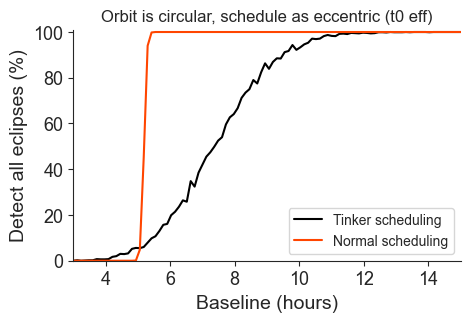

In [84]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_circ_ecc * 100, color = 'black', label = 'Tinker scheduling')
plt.plot(tbaselines3, detectability3 * 100, color = 'orangered', label = 'Normal scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Orbit is circular, schedule as eccentric (t0 eff)')
plt.legend()
plt.ylim(0,101)
plt.show()

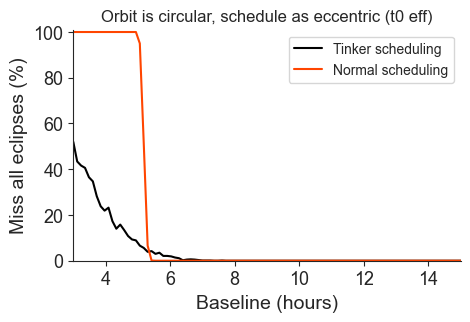

In [85]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_circ_ecc * 100, color = 'black', label = 'Tinker scheduling')
plt.plot(tbaselines3, non_detectability3 * 100, color = 'orangered', label = 'Normal scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Orbit is circular, schedule as eccentric (t0 eff)')
plt.legend()
plt.ylim(0,101)
plt.show()

It changes a bit, but not by much in this case. What about other parameters?

### 3.3 Using eccentric eclipse uncertainties as the randomization parameters --- but the mean between the circular-ecc t0's, 1/2-hour error on t0 randomization

In [86]:
detectability_ls_ecc_ecc = np.zeros( len(tbaselines) )
non_detectability_ls_ecc_ecc = np.zeros( len(tbaselines) )

t0_effective = ( t0_eclipse_circular + t0_eclipse_eccentric ) * 0.5

for k in range( len(tbaselines) ):

    detectability_ls_ecc_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             t0_effective, 0.5/24.,
                                                             P_eccentric, P_eccentric_error, 
                                                             success_number = neclipses)

    non_detectability_ls_ecc_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_eccentric, t0_eclipse_eccentric_error,
                                                             P_eccentric, P_eccentric_error,
                                                             t0_effective, 0.5/24.,
                                                             P_eccentric, P_eccentric_error,
                                                             success_number = 0)

In [87]:
detectability_ls_circ_ecc = np.zeros( len(tbaselines) )
non_detectability_ls_circ_ecc = np.zeros( len(tbaselines) )

for k in range( len(tbaselines) ):

    detectability_ls_circ_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_circular, t0_eclipse_circular_error,
                                                             P_circular, P_circular_error,
                                                             t0_eclipse_eccentric, 0.5/24.,
                                                             P_eccentric, P_eccentric_error, 
                                                             success_number = neclipses)

    non_detectability_ls_circ_ecc[k] = eccentric_lucky_experiment(tbaselines[k], 
                                                             t0_eclipse_circular, t0_eclipse_circular_error,
                                                             P_circular, P_circular_error,
                                                             t0_eclipse_eccentric, 0.5/24.,
                                                             P_eccentric, P_eccentric_error,
                                                             success_number = 0)

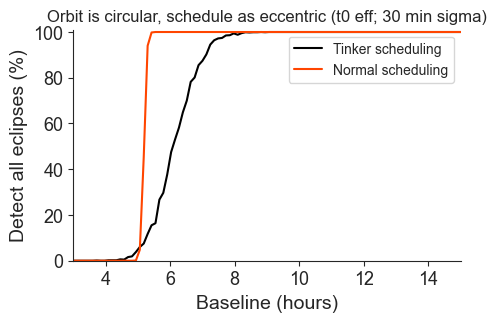

In [88]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_circ_ecc * 100, color = 'black', label = 'Tinker scheduling')
plt.plot(tbaselines3, detectability3 * 100, color = 'orangered', label = 'Normal scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Orbit is circular, schedule as eccentric (t0 eff; 30 min sigma)')
plt.legend()
plt.ylim(0,101)
plt.show()

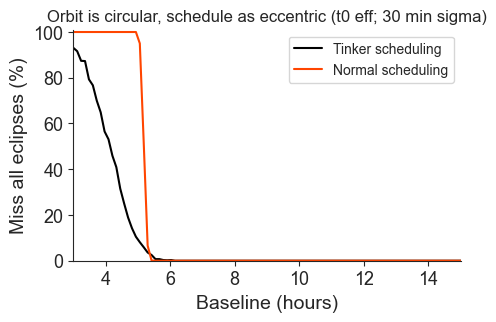

In [89]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_circ_ecc * 100, color = 'black', label = 'Tinker scheduling')
plt.plot(tbaselines3, non_detectability3 * 100, color = 'orangered', label = 'Normal scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Orbit is circular, schedule as eccentric (t0 eff; 30 min sigma)')
plt.legend()
plt.ylim(0,101)
plt.show()

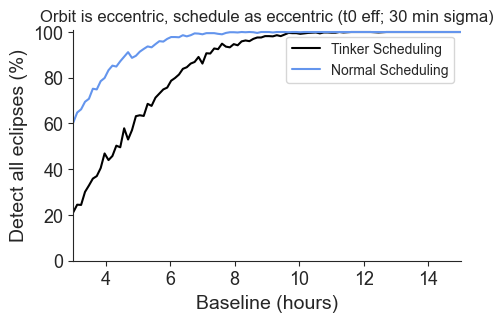

In [90]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_ecc_ecc * 100, color = 'black', label = 'Tinker Scheduling')
plt.plot(tbaselines2, detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric (t0 eff; 30 min sigma)')
plt.legend()
plt.ylim(0,101)
plt.show()

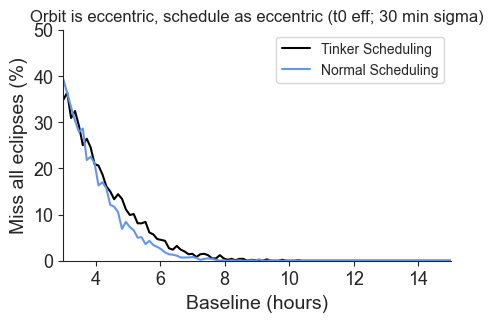

In [91]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_ecc_ecc * 100, color = 'black', label = 'Tinker Scheduling')
plt.plot(tbaselines2, non_detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric (t0 eff; 30 min sigma)')
plt.legend()
plt.ylim(0,50)
plt.show()

So in this case, you converge back to normal scheduling!

## 4. Experiment 3: tinker scheduling forcing circular solution included

On this last experiment, we play with the idea that we want a _variable_ baseline for each observation. This should comply with the following:

1. It should cover the sampled random eclipse time.
2. It should _also_ be forced to always cover the circular eclipse time.

The thinking here is that we might have a prior that if the orbit is not very eccentric, then orbit is likely circular, so we want to prioritize that if it turns out to be that way, we capture the event.

Let's first do an excercise on which we have a pre-define base-baseline. Then we'll generalize to do plots for many baselines to see the optimal

### Pre-defined base baseline

Let's define a function that runs this experiment:

In [92]:
def tinker_schedule(j, pre_eclipse_midtime, post_eclipse_midtime,
                    t0_mean, t0_sigma,
                    P_mean, P_sigma, 
                    t0_circular, P_circular, pre_post_circular, T14_circular, add_one_hour = True):
    """
    This function applies tinker scheduling, returning tstart and the final tinker scheduling baseline after tstart to schedule 
    the observations at epoch j. Given t0 ~ N(t0_mean, t0_sigma) and P ~ N(P_mean, P-sigma), together with the parameters of the 
    circular ephemerides, this returns new times of start and baseline that covers both the randomized baseline and also the 
    circular solution.

    Inputs
    ------
    
    j:                      Epoch of the observation (with epoch j = 0 corresponding to t0, j = 1 to t0 + P, etc.).
    pre_eclipse_midtime:    Time (in hours) spent before eclipse mid-time.
    post_eclipse_midtime:   Time (in hours) spent after the eclipse mid-time.
    t0_mean:                Tinker scheduling eclipse time mean.
    t0_sigma:               Tinker scheduling eclipse time standard deviation.
    P_mean:                 Tinker scheduling eclipse period mean.
    P_sigma:                Tinker scheduling eclipse period standard deviation:
    t0_circular:            Best-fit time-of-eclipse in the circular case.
    P_circular:             Best-fit period in the circular case.
    pre_post_circular:      The scheduling will add this ammount of time (in hours) to catch eclipse if circular either prior or after 
                            the circular predicted time of eclipse.
    T14_circular:           T14 of the eclipse in the circular case (in hours)
    add_one_hour:           Boolean (optional). If true, add an extra hour at the end of the baseline to account for the uncertainty 
                            in the phase constraint window.
    """

    # Schedule via tinker scheduling with circular eclipse-time constraint. First, sample the t0 and P from tinker scheduling:
    t0 = np.random.normal(t0_mean, t0_sigma)
    P = np.random.normal(P_mean, P_sigma)

    # Compute the "baseline" time of start:
    tstart = t0 + P * j - ( pre_eclipse_midtime ) / 24.
    tbaseline = pre_eclipse_midtime + post_eclipse_midtime
    tend = tstart + ( tbaseline / 24. )
    # Check where the time of circular eclipse is at this epoch:
    tcirc = t0_circular + P_circular * j
    beg_circ = tcirc - (T14_circular / 24.) * 0.5 - (pre_post_circular / 24.)
    end_circ = tcirc + (T14_circular / 24.) * 0.5 + (pre_post_circular / 24.)
    # Check if the circular time of eclipse plus/minus pre-circular baseline, falls at various portions. First, if it falls after:
    if end_circ > tend:

        # If this is the case, simply enlarge the baseline by the difference:
        new_tbaseline = (end_circ - tend) * 24 + tbaseline
        new_tstart = tstart

    elif beg_circ < tstart:

        # In this case, we are late --- so modify both tbaseline and tstart:
        new_tbaseline = (tstart - beg_circ) * 24 + tbaseline
        new_tstart = beg_circ

    else:

        # If none of the other cases show up, we stay with our selection because we contain the circular case:
        new_tbaseline = tbaseline + 0.
        new_tstart = tstart + 0.

    if add_one_hour:

        return new_tstart, new_tbaseline + 1.
    
    else:
        
        return new_tstart, new_tbaseline
    

def force_circular_lucky_experiment(tbaseline, 
                                    true_t0, true_t0_error, 
                                    true_P, true_P_error,
                                    true_T14,
                                    t0_circular, P_circular, pre_post_circular, T14_circular,
                                    t0_mean, t0_sigma, 
                                    P_mean, P_sigma,
                                    success_number,
                                    neclipses,
                                    nsimulation = 100
                                    ):

    """
    Input:
    
        tbaseline:          Baseline duration in hours
        true_t0:            Mean of the best-fit time-of-eclipse t0 (i.e., the one you get from either a circular or eccentric fit).
        true_t0_error:      Standard deviation of this best-fit t0.
        true_P:             Same as true_t0, but for the period P of the orbit.
        true_P_error:       Same as true_t0_error but for period P of the orbit.
        true_T14:           True duration of the orbit
        t0_circular:        Best-fit time-of-eclipse in the circular case.
        P_circular:         Best-fit period in the circular case.
        pre_post_circular:  The scheduling will add this ammount of time (in hours) to catch eclipse if circular either prior or after 
                            the circular predicted time of eclipse.
        T14_circular:       T14 of the eclipse in the circular case (in hours)
    
        t0_mean:            Mean of the t0 distribution used to preform tinker scheduling.
        t0_sigma:           Standard deviation of this distribution.
        P_mean:             Mean of the P distribution used to perform tinker scheduling.
        P_sigma:            Standard deviation of this P distribution.
    
        success_number:     Function returns fraction of times success_number successes are seen in the nsimulation trials.
        neclipses:          Number of eclipses in the simulation.
        nsimulation:        Number of simulations (default is 100)

    Returns:

        success_fraction:   fraction of success_number that ocurrs in all sims
        telescope_times:    distribution of telescope time on the experiment
    
    """

    # Draw nsimulation t0s:
    t0s = np.random.normal(true_t0, true_t0_error, nsimulation)
    # Same for P:
    Ps = np.random.normal(true_P, true_P_error, nsimulation)
    # Successes per simulation:
    nsuccesses = np.zeros(nsimulation)
    telescope_times = np.zeros(nsimulation)
    
    for i in range(nsimulation):
    
        trials = np.zeros(neclipses)
        total_telescope_time = 0.
        for j in range(neclipses):

            new_tstart, new_tbaseline = tinker_schedule(j, tbaseline / 2., tbaseline / 2.,
                                                        t0_mean, t0_sigma,
                                                        P_mean, P_sigma, 
                                                        t0_circular, P_circular, pre_post_circular, T14_circular)

            total_telescope_time += new_tbaseline
            trials[j] = is_eclipse(t0s[i], Ps[i], true_T14, new_tstart, new_tbaseline)

        nsuccesses[i] = np.sum(trials)
        telescope_times[i] = total_telescope_time + 0.

    return float( len(np.where(nsuccesses == success_number)[0]) ) / nsimulation, telescope_times

Let's try it once for our circular case:

In [93]:
tbaseline = 5
true_t0, true_t0_err = t0_eclipse_circular, t0_eclipse_circular_error
true_P, true_P_err = P_circular, P_circular_error
t0_lucky, t0_lucky_sigma = t0_eclipse_eccentric, t0_eclipse_eccentric_error
P_lucky, P_lucky_sigma = P_eccentric, P_eccentric_error

frac, tdist = force_circular_lucky_experiment(tbaseline, 
                                             true_t0, true_t0_err,
                                             true_P, true_P_err,
                                             T14_circular,
                                             t0_eclipse_circular, P_circular, 1.0, T14_circular,
                                             t0_lucky, t0_lucky_sigma,
                                             P_lucky, P_lucky_sigma, 
                                             success_number = neclipses, 
                                             neclipses = neclipses,
                                             nsimulation = 1000)

Do we get 100% detections?

In [94]:
frac

1.0

Good! What about the extra telescope time --- how much is it?

(array([ 22., 106., 179., 220., 220., 144.,  59.,  37.,  10.,   3.]),
 array([ 4.18542195,  5.34159341,  6.49776488,  7.65393635,  8.81010781,
         9.96627928, 11.12245075, 12.27862221, 13.43479368, 14.59096515,
        15.74713661]),
 <BarContainer object of 10 artists>)

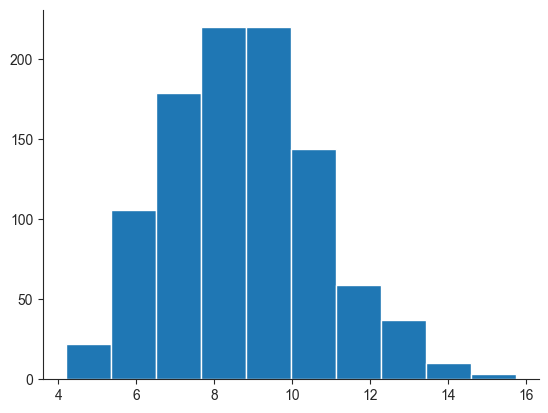

In [95]:
plt.hist( tdist - (tbaseline*neclipses) )

In [96]:
extra_time_median = np.nanmedian(tdist - (tbaseline*neclipses))
extra_time_sigma = np.sqrt(np.var(tdist - (tbaseline*neclipses)))

In [97]:
print('{0:.2f} {1:.2f}'.format(extra_time_median, extra_time_sigma))

8.64 1.94


Neat. On average an extra 11 +/- 2 hours of telescope time for this baseline. 

### Other baselines

How does the pre-baseline map with the extra telescope time?

In [98]:
extra_time = np.zeros(len(tbaselines))
extra_time_error = np.zeros(len(tbaselines))

In [99]:
for i in range(len(tbaselines)):

    frac, tdist = force_circular_lucky_experiment(tbaselines[i], 
                                             true_t0, true_t0_err,
                                             true_P, true_P_err,
                                             T14_circular,
                                             t0_eclipse_circular, P_circular, 1.0, T14_circular,
                                             t0_lucky, t0_lucky_sigma,
                                             P_lucky, P_lucky_sigma, 
                                             success_number = neclipses, 
                                             neclipses = neclipses,
                                             nsimulation = 1000)

    extra_time[i] = np.nanmedian(tdist - (tbaselines[i]*neclipses))
    extra_time_error[i] = np.sqrt(np.var(tdist - (tbaselines[i]*neclipses)))

(array([ 2.,  4.,  6.,  8., 10., 12., 14., 16.]),
 [Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14'),
  Text(0, 16.0, '16')])

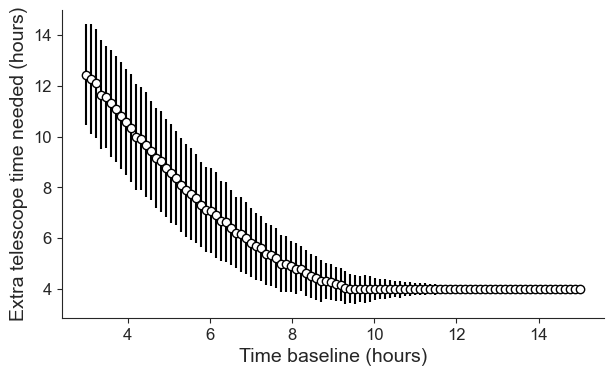

In [100]:
plt.figure(figsize = (7,4))

plt.errorbar(tbaselines, extra_time, extra_time_error, fmt = 'o', mfc = 'white', mec = 'black', ecolor = 'black')

plt.xlabel('Time baseline (hours)', fontsize = 14)
plt.ylabel('Extra telescope time needed (hours)', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

In percentage:

(array([  0.,  20.,  40.,  60.,  80., 100., 120., 140.]),
 [Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60'),
  Text(0, 80.0, '80'),
  Text(0, 100.0, '100'),
  Text(0, 120.0, '120'),
  Text(0, 140.0, '140')])

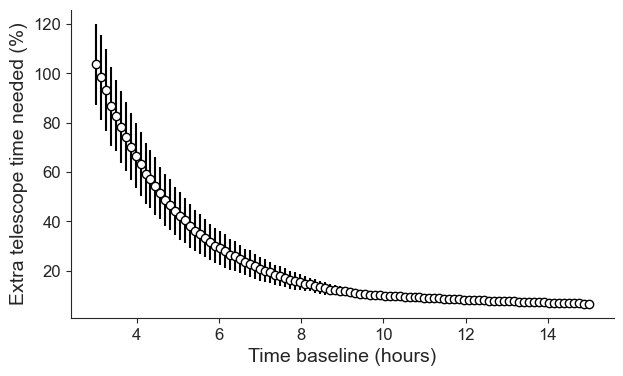

In [101]:
plt.figure(figsize = (7,4))

plt.errorbar(tbaselines, 100 * ( extra_time / ( tbaselines*neclipses ) ), 
                         100 * (extra_time_error / ( tbaselines*neclipses )) , fmt = 'o', mfc = 'white', mec = 'black', ecolor = 'black')

plt.xlabel('Time baseline (hours)', fontsize = 14)
plt.ylabel('Extra telescope time needed (%)', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

All right, so this covers the circular case. Does this extra tinkering help with the eccentric case itself (i.e., you have a bit more effective time, your success rate should go up). Let's do some simulations similar to the ones made above:

In [102]:
true_t0, true_t0_err = t0_eclipse_eccentric, t0_eclipse_eccentric_error
true_P, true_P_err = P_eccentric, P_eccentric_error

detectability_ls_ecc_ecc_vbaseline = np.zeros( len(tbaselines) )
non_detectability_ls_ecc_ecc_vbaseline = np.zeros( len(tbaselines) )

for k in range( len(tbaselines) ):    

    detectability_ls_ecc_ecc_vbaseline[k], tdist = force_circular_lucky_experiment(tbaselines[k], 
                                                                               true_t0, true_t0_err,
                                                                               true_P, true_P_err,
                                                                               T14_circular,
                                                                               t0_eclipse_circular, P_circular, 1.0, T14_circular,
                                                                               t0_lucky, t0_lucky_sigma,
                                                                               P_lucky, P_lucky_sigma, 
                                                                               success_number = neclipses, 
                                                                               neclipses = neclipses,
                                                                               nsimulation = 1000)

    non_detectability_ls_ecc_ecc_vbaseline[k], _ = force_circular_lucky_experiment(tbaselines[k], 
                                                                               true_t0, true_t0_err,
                                                                               true_P, true_P_err,
                                                                               T14_circular,
                                                                               t0_eclipse_circular, P_circular, 1.0, T14_circular,
                                                                               t0_lucky, t0_lucky_sigma,
                                                                               P_lucky, P_lucky_sigma, 
                                                                               success_number = 0, 
                                                                               neclipses = neclipses,
                                                                               nsimulation = 1000)
        


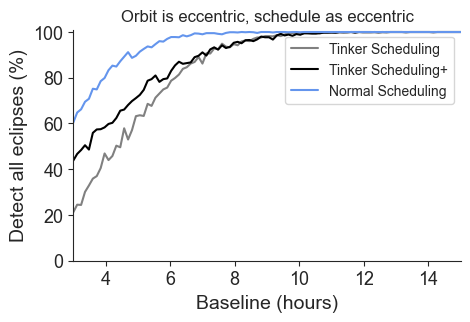

In [103]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, detectability_ls_ecc_ecc * 100, color = 'grey', label = 'Tinker Scheduling')
plt.plot(tbaselines, detectability_ls_ecc_ecc_vbaseline * 100, color = 'black', label = 'Tinker Scheduling+')
plt.plot(tbaselines2, detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Detect all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric')
plt.legend()
plt.ylim(0,101)
plt.show()

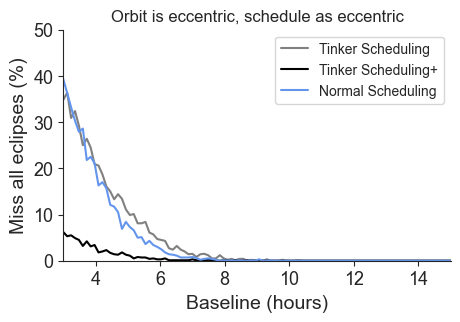

In [104]:
plt.figure(figsize = (5, 3))
plt.plot(tbaselines, non_detectability_ls_ecc_ecc * 100, color = 'grey', label = 'Tinker Scheduling')
plt.plot(tbaselines, non_detectability_ls_ecc_ecc_vbaseline * 100, color = 'black', label = 'Tinker Scheduling+')
plt.plot(tbaselines2, non_detectability2 * 100, color = 'cornflowerblue', label = 'Normal Scheduling')
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xlim(np.min(tbaselines2), np.max(tbaselines2))
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Baseline (hours)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Orbit is eccentric, schedule as eccentric')
plt.legend()
plt.ylim(0,50)
plt.show()

Excellent! Success indeed goes up. 

### Probability of success with 3, 4 or 5-hour pre-baselines

How do the nice histograms with the number of successes change with this upgraded Tinker scheduling between a base of 4 or 5 hours? Let's test 5 first:

In [105]:
n_eclipses = np.arange(0,neclipses+1)
rate = np.zeros(len(n_eclipses))

for i in range(len(n_eclipses)):
    
    rate[i], _ = force_circular_lucky_experiment(5, 
                                                 true_t0, true_t0_err,
                                                 true_P, true_P_err,
                                                 T14_circular,
                                                 t0_eclipse_circular, P_circular, 1.0, T14_circular,
                                                 t0_lucky, t0_lucky_sigma,
                                                 P_lucky, P_lucky_sigma, 
                                                 success_number = n_eclipses[i], 
                                                 neclipses = neclipses,
                                                 nsimulation = 1000, 
                                                 )


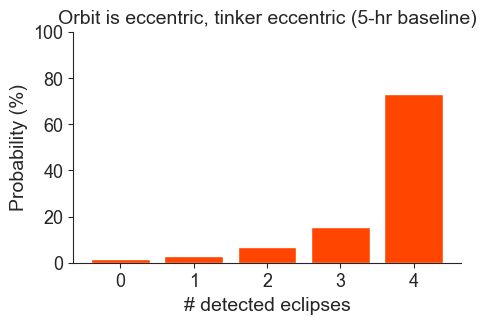

In [106]:
plt.figure(figsize = (5, 3))
plt.bar(n_eclipses, rate*100, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.title('Orbit is eccentric, tinker eccentric (5-hr baseline)', fontsize = 14)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('Probability (%)', fontsize = 14)
plt.ylim(0,100)
plt.show()

In [107]:
print(np.round(np.sum(rate[3:]*100),2), '% probability')

88.4 % probability


So the probability of getting 3 eclipses or more is quite high in this case. It _really_ goes up! What about the 4-hour base-baseline case:

In [108]:
n_eclipses = np.arange(0,neclipses+1)
rate = np.zeros(len(n_eclipses))

for i in range(len(n_eclipses)):
    
    rate[i], _ = force_circular_lucky_experiment(4, 
                                                 true_t0, true_t0_err,
                                                 true_P, true_P_err,
                                                 T14_circular,
                                                 t0_eclipse_circular, P_circular, 1.0, T14_circular,
                                                 t0_lucky, t0_lucky_sigma,
                                                 P_lucky, P_lucky_sigma, 
                                                 success_number = n_eclipses[i], 
                                                 neclipses = neclipses,
                                                 nsimulation = 1000, 
                                                )


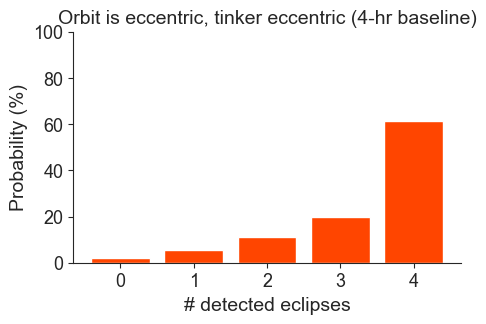

In [109]:
plt.figure(figsize = (5, 3))
plt.bar(n_eclipses, rate*100, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.title('Orbit is eccentric, tinker eccentric (4-hr baseline)', fontsize = 14)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('Probability (%)', fontsize = 14)
plt.ylim(0,100)
plt.show()

In [110]:
print(np.round(np.sum(rate[3:]*100),2), '% probability')

80.9 % probability


In [111]:
n_eclipses = np.arange(0,neclipses+1)
rate = np.zeros(len(n_eclipses))

for i in range(len(n_eclipses)):
    
    rate[i], _ = force_circular_lucky_experiment(3, 
                                                 true_t0, true_t0_err,
                                                 true_P, true_P_err,
                                                 T14_circular,
                                                 t0_eclipse_circular, P_circular, 1.0, T14_circular,
                                                 t0_lucky, t0_lucky_sigma,
                                                 P_lucky, P_lucky_sigma, 
                                                 success_number = n_eclipses[i], 
                                                 neclipses = neclipses,
                                                 nsimulation = 1000, 
                                                )


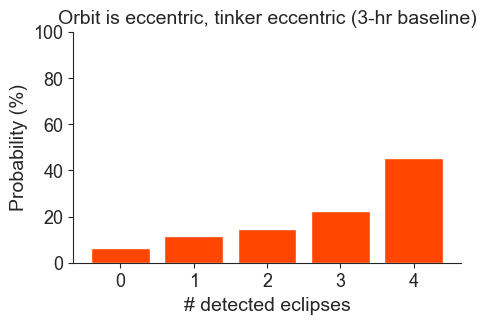

In [112]:
plt.figure(figsize = (5, 3))
plt.bar(n_eclipses, rate*100, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.title('Orbit is eccentric, tinker eccentric (3-hr baseline)', fontsize = 14)
plt.xlabel('# detected eclipses', fontsize = 14)
plt.ylabel('Probability (%)', fontsize = 14)
plt.ylim(0,100)
plt.show()

In [113]:
print(np.round(np.sum(rate[3:]*100),2), '% probability')

67.7 % probability


## 5. Defining the final scheduling parameters

We now turn to define the final scheduling parameters, together with some visuals. Let's first write a function that, given a (corrected) time-baseline, visually tells us the expected scheduling in phase. We make this function particularly general as it might come in handy in the future to compare against observed time-series observations:

In [114]:
def plot_schedule(tstart, tend, 
                  t0_eclipse_circular, t0_eclipse_circular_error, T14_circular, P_circular, 
                  t0_eclipse_eccentric, t0_eclipse_eccentric_error, T14_eccentric, P_eccentric,
                  detector_settling = 0.,
                  fpfs = 100,
                  nsim = 100, 
                  min_t = -10, max_t = 10, 
                  title = None,
                  one_hour_padding = False,
                  breaks = [],
                  save = False):

    """
    This function plots a particular scheduling setup. 

    Inputs
    ------

        tstart:                           List of expected start of observations in BJD.
        tend:                             List of expected end of observations in BJD.
        t0_eclipse_circular:              Time-of-secondary eclipse in the circular case (days).
        t0_eclipse_circular_error:        Error on the t0_eclipse_circular (days).
        T14_circular:                     T14 for circular eclipse (hours).
        t0_eclipse_eccentric:             Time-of-secondary eclipse in the eccentric case (days).
        t0_eclipse_eccentric_error:       Error on the t0_eclipse_eccentric (days).
        P_eccentric:                      Orbital period of the eccentric solution (days).
        T14_eccentric:                    T14 for eccentric eclipse (hours).
        detector_settling:                (Optional) If non-zero, add this as a yellow line in the plot to mark extra ds time (hours)
        fpfs:                             (Optional) Fp/Fs to plot.
        nsim:                             (Optional) Number of times to sample eclipses for plot.
        min_t:                            (Optional) Minimum time (in hours) to plot/evaluate models at.
        max_t:                            (Optional) Maximum time (in hours) to plot/evaluate models at.
        title:                            (Optional) Title of the plot.
        one_hour_padding:                 (Optional) Plot the one-hour padding at the end due to the phase constraint.
        breaks:                           (Optional) List of breaks for the observations to plot (for very long exposures); this is 
                                                     in hours after start of observations, assuming observations start at the 
                                                     earliest phase-constraint time
        save:                             (Optional) If True, save plot with the name of the title.
    """

    # Generate circular eclipse:
    tcirc = np.random.normal(t0_eclipse_circular, t0_eclipse_circular_error, nsim)
    tecc = np.random.normal(t0_eclipse_eccentric, t0_eclipse_eccentric_error, nsim)

    plt.figure( figsize=(10, 4) )
    
    for i in range(nsim):
        
        tc,fc = generate_eclipse(tcirc[i], P_circular, T14_circular, 
                                 t0_eclipse_circular + min_t / 24., max_t-min_t, 
                                 depth = fpfs, npoints = 1000)

        plt.plot( ( tc - t0_eclipse_circular ) * 24, (fc - 1.) * 1e6 + fpfs, color = 'orangered', alpha = 0.1)

        te,fe = generate_eclipse(tecc[i], P_eccentric, T14_eccentric, 
                                 t0_eclipse_circular + min_t / 24., max_t-min_t, 
                                 depth = fpfs, npoints = 1000)

        plt.plot( ( te - t0_eclipse_circular ) * 24, (fe - 1.) * 1e6 + fpfs, color = 'cornflowerblue', alpha = 0.1)

    # Also plot the median values themselves:
    tc,fc = generate_eclipse(t0_eclipse_circular, P_circular, T14_circular, 
                             t0_eclipse_circular + min_t / 24., max_t-min_t, 
                             depth = fpfs, npoints = 1000)
    
    plt.plot( ( tc - t0_eclipse_circular ) * 24, (fc - 1.) * 1e6 + fpfs, color = 'red', lw = 2)


    te,fe = generate_eclipse(t0_eclipse_eccentric, P_eccentric, T14_eccentric, 
                             t0_eclipse_circular + min_t / 24., max_t-min_t, 
                             depth = fpfs, npoints = 1000)

    plt.plot( ( te - t0_eclipse_circular ) * 24, (fe - 1.) * 1e6 + fpfs, color = 'royalblue', lw = 2)

    dfpfs = 20
    first_break = True
    for i in range(len(tstart)): 

        offset = fpfs + dfpfs*i + dfpfs
        
        if i == 0:
            
            plt.plot( [ (tstart[i] - t0_eclipse_circular) * 24., (tend[i] - t0_eclipse_circular) * 24.], 
                      [ offset, offset], 
                     lw = 4, 
                     color = 'black', label = 'Expected time-baseline')

            if one_hour_padding:

                plt.plot( [ (tstart[i] - t0_eclipse_circular) * 24. - 1.0, (tend[i] - t0_eclipse_circular) * 24.], 
                          [ offset, offset], 
                         lw = 4, 
                         color = 'black', alpha = 0.5)

            if detector_settling != 0.:

                plt.plot( [ (tstart[i] - t0_eclipse_circular) * 24., (tstart[i] - t0_eclipse_circular) * 24. + detector_settling ],
                          [ offset, offset ],
                         lw = 2,
                         color = 'darkorange', label = 'Detector settling' )

            if one_hour_padding:

                plt.plot( [ (tend[i] - t0_eclipse_circular) * 24. - 1., (tend[i] - t0_eclipse_circular) * 24. ],
                          [ offset, offset ],
                         lw = 2,
                         color = 'lightgrey', label = 'Phase-constraint padding' )  

        else:

            plt.plot( [ (tstart[i] - t0_eclipse_circular) * 24., (tend[i] - t0_eclipse_circular) * 24.], 
                      [ offset, offset], 
                     lw = 4, 
                     color = 'black')

            if one_hour_padding:

                plt.plot( [ (tstart[i] - t0_eclipse_circular) * 24. - 1.0, (tend[i] - t0_eclipse_circular) * 24.], 
                          [ offset, offset], 
                         lw = 4, 
                         color = 'black', alpha = 0.5)
            
            if detector_settling != 0.:
    
                plt.plot( [ (tstart[i] - t0_eclipse_circular) * 24., (tstart[i] - t0_eclipse_circular) * 24. + detector_settling ],
                          [ offset, offset ],
                         lw = 2,
                         color = 'darkorange' )

            if one_hour_padding:

                plt.plot( [ (tend[i] - t0_eclipse_circular) * 24. - 1., (tend[i] - t0_eclipse_circular) * 24. ],
                          [ offset, offset ],
                         lw = 2,
                         color = 'lightgrey')



        if len(breaks) != 0:

            if len(breaks[i]) != 0:

                for b in breaks[i]:

                    if first_break:

                        plt.scatter([(tstart[i] - t0_eclipse_circular) * 24. - 1.0 + b], [ offset ], 
                                    marker='v', s=100, c='orangered', zorder = 100,
                                    label = 'Exposure break')

                        first_break = False

                    else:
                        
                        plt.scatter([(tstart[i] - t0_eclipse_circular) * 24. - 1.0 + b], [ offset ], 
                                    marker='v', s=100, c='orangered', zorder = 100)
                        
        
        tb = ( tend[i] - tstart[i] ) * 24.
        plt.text( (tend[i] - t0_eclipse_circular) * 24. + 0.5, offset - dfpfs * (1./7.), 'Observation '+str(i+1)+' ({0:.1f} hrs)'.format(tb) )

    plt.plot([], [], color = 'orangered', label = 'Circular solution')
    plt.plot([], [], color = 'cornflowerblue', label = 'Eccentric solution')
    plt.xlim(min_t,max_t)
    plt.ticklabel_format(useOffset=False)

    if title is not None:

        plt.title(title, fontsize = 16, y=1.1)
        
    plt.xlabel('Time since circular secondary eclipse (hours)', fontsize = 16)
    plt.ylabel('Relative flux', fontsize = 16)
    plt.xticks(fontsize = 14)
    plt.yticks(fontsize = 14)

    plt.tight_layout()
    plt.legend(loc='lower right', frameon=False)

    if save:
        
        plt.savefig(title.replace(" ", "-")+'.pdf', dpi = 300)
        
    plt.show()

Let's check that it works:

In [115]:
all_tstart = [t0_eclipse_circular - 6./24., 
              t0_eclipse_circular - 3./24.,
              t0_eclipse_circular - 1./24.]

all_tend = [t0_eclipse_circular + (6./24.), 
            t0_eclipse_circular + (1./24.), 
            t0_eclipse_circular + (7./24.)]

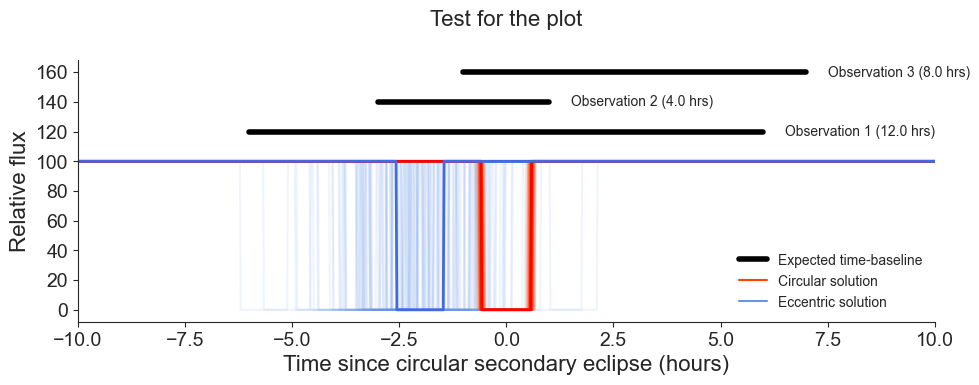

In [116]:
plot_schedule(all_tstart, all_tend, 
              t0_eclipse_circular, t0_eclipse_circular_error, T14_circular, P_circular, 
              t0_eclipse_eccentric, t0_eclipse_eccentric_error, T14_eccentric, P_eccentric, 
              fpfs = 100,
              nsim = 100,
              title = 'Test for the plot', 
              save = True)

It does! All right, now let's calculate the actual `tstart` and `tend` using our "final" tinker scheduling technique (i.e., the one in Section 4 above). 

Let's generate 4 tinker-scheduled time-of-starts and baselines using the technique at epoch 0 --- this is because I've already set the times of eclipse in the circular and eccentric cases to end-of-April. Here I'm assuming that uncertainties won't change much in the next few months. We do many samples, and save the corresponding tinker schedules --- we will then do the risk versus total telescope time plot:

In [117]:
epoch = 0                  # Set epoch to 0, which is end of April 2025. In theory, you can do tinker scheduling for different dates;
                           # here we simplify the approach assuming uncertainty on ephemerides will not change much for these first 
                           # observations.

pre_post_circular = 1.     # 1-hour post baseline --- here makes sense because in general, circular eclipse is after eccentric,
                           # and systematics at the end are not as bad as for the beggining.

pre_tbaseline = 2.         # Baseline prior to applying tinker scheduling in hours. 

n_eclipses = 4             # First checkpoint will be 4 eclipses.

detector_settling = 0.75   # Hours we'll pad to the start of the observations for detector settling (i.e., the ramp). 

nschedules = 1000          # How many schedules we want to sample with those parameters

schedules = []
schedules_time = []

for k in range(nschedules):

    all_tstart = []
    all_tend = []
    all_tbaseline = []
    total_telescope_time = 0.
    
    for i in range(n_eclipses):
    
        tstart, tbaseline = tinker_schedule(
                            0, pre_tbaseline * 0.5, pre_tbaseline * 0.5,               # epoch = 0; same pre/post mid-transit baseline
                            t0_eclipse_eccentric, t0_eclipse_eccentric_error,          # Tinker scheduling parameters
                            P_eccentric, P_eccentric_error,                            # Tinker scheduling parameters
                            t0_eclipse_circular, P_circular, pre_post_circular, T14_circular)  # Circular eclipse parameters
    
        # Add the detector settling time to both tstart and tbaseline:
        tstart -= ( detector_settling / 24.)
        tbaseline += detector_settling
    
        # Save:
        all_tstart.append(tstart + 0. )
        all_tend.append(tstart + (tbaseline / 24.) )
        all_tbaseline.append(tbaseline)
        
        total_telescope_time += tbaseline

    schedules.append( [all_tstart, all_tend, all_tbaseline] )
    schedules_time.append( total_telescope_time )

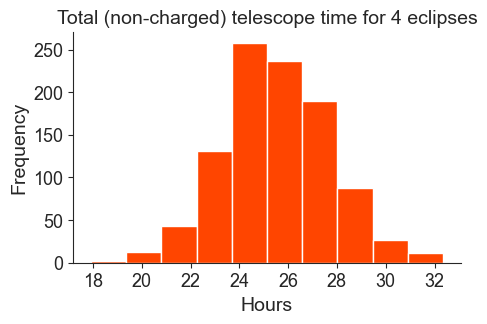

In [118]:
plt.figure(figsize = (5, 3))
plt.hist(schedules_time, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.title('Total (non-charged) telescope time for {0:} eclipses'.format(neclipses), fontsize = 14)
plt.xlabel('Hours', fontsize = 14)
plt.ylabel('Frequency', fontsize = 14)
plt.show()

Calculate the risk of not detecting any eclipse for each of those sampled schedules in the eccentric case:

In [119]:
def estimate_risk(schedule, 
                  t0_eclipse_eccentric, t0_eclipse_eccentric_error, T14_eccentric, P_eccentric, P_eccentric_error,
                  detector_settling,
                  nsimulation = 1000,
                  success_number = 0):


    # Draw nsimulation t0s:
    t0s = np.random.normal(t0_eclipse_eccentric, t0_eclipse_eccentric_error, nsimulation)
    # Same for P:
    Ps = np.random.normal(P_eccentric, P_eccentric_error, nsimulation)
    # Successes per simulation:
    nsuccesses = np.zeros(nsimulation)
    # Extract input schedule:
    all_tstart, all_tend, all_tbaseline = schedule
    neclipses = len( all_tstart )
    
    for i in range(nsimulation):
    
        trials = np.zeros(neclipses)
        for j in range(neclipses):

            tbaseline = all_tend[j] - ( all_tstart[j] +  ( detector_settling / 24. ) ) 
            trials[j] = is_eclipse(t0s[i], Ps[i], T14_eccentric, all_tstart[j] + ( detector_settling / 24. ), tbaseline * 24.)

        nsuccesses[i] = np.sum(trials)

    return float( len(np.where(nsuccesses == success_number)[0]) ) / nsimulation

In [120]:
risks = np.zeros( nschedules ) 

for i in range(nschedules):
    
    risks[i] = estimate_risk(schedules[i],
                             t0_eclipse_eccentric, t0_eclipse_eccentric_error, T14_eccentric, P_eccentric, P_eccentric_error,
                             detector_settling)

Plot risks of missing all eclipses in the eccentric case versus total telescope time:

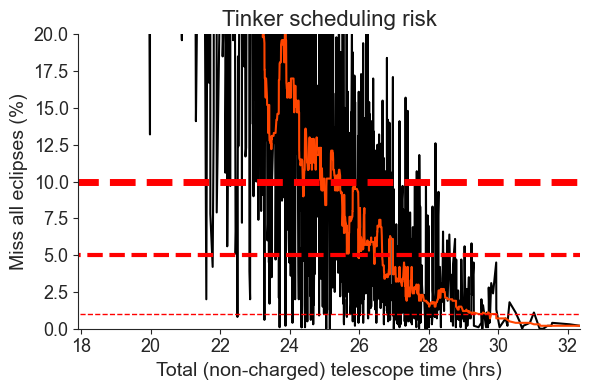

In [135]:
idx = np.argsort( np.array(schedules_time) )
mf = median_filter(risks[idx] * 100, 30)

plt.figure(figsize = (6, 4))
plt.plot( np.array( schedules_time )[idx], risks[idx] * 100, color = 'black')
plt.plot( np.array( schedules_time )[idx], mf, color = 'orangered')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('Total (non-charged) telescope time (hrs)', fontsize = 14)
plt.ylabel('Miss all eclipses (%)', fontsize = 14)
plt.title('Tinker scheduling risk', fontsize = 16)
plt.plot([np.min(schedules_time)-10, np.max(schedules_time)+10], [1, 1], 'r--', lw = 1)
plt.plot([np.min(schedules_time)-10, np.max(schedules_time)+10], [5, 5], 'r--', lw = 3)

plt.plot([np.min(schedules_time)-10, np.max(schedules_time)+10], [10, 10], 'r--', lw = 5)
plt.xlim(np.min(schedules_time), np.max(schedules_time))
plt.ylim(0,20)
plt.tight_layout()
plt.savefig('GJ3929_risk.pdf')
plt.show()

Pick a tolerance of 10% risk of missing all eclipses if orbit is eccentric, which is a total (non-charged) telescope time of about 25 hours. Pick the smallest among all the schedules with > 25 hours:

In [122]:
idx = np.where( np.array(schedules_time) >= 25 )
st = np.min( np.array(schedules_time)[idx] )
idx = np.where( np.array(schedules_time)  == st )[0]

all_tstart, all_tend, all_tbaseline = schedules[idx[0]] 
total_telescope_time = np.sum(all_tbaseline)

Order the selected tinker scheduling observing windows from smaller baseline to larger:

In [123]:
idx = np.argsort(np.array(all_tbaseline))

all_tstart = np.array(all_tstart)[idx]
all_tend = np.array(all_tend)[idx]
all_tbaseline = np.array(all_tbaseline)[idx]

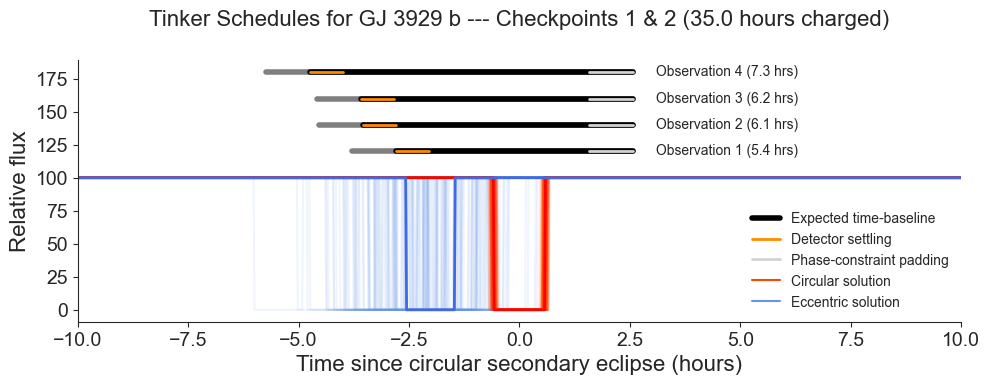

In [129]:
plot_schedule(all_tstart, all_tend, 
              t0_eclipse_circular, t0_eclipse_circular_error, T14_circular, P_circular, 
              t0_eclipse_eccentric, t0_eclipse_eccentric_error, T14_eccentric, P_eccentric,
              detector_settling = detector_settling,
              fpfs = 100,
              nsim = 100,
              title = 'Tinker Schedules for GJ 3929 b --- Checkpoints 1 & 2 ({1:.1f} hours charged)'.format(total_telescope_time, total_telescope_time*1.4),
              one_hour_padding = True,
              breaks = [[],[],[],[]],
              save = True)

Excellent, now let's compute the corresponding phase-constraints to these start and end times. We do this using the following function:

In [125]:
def compute_phase_constraint(tstart, tend, P):
    """
    Given a time-of-start and time-of-end of an observation, compute a phase constraint given a period P. 
    This returns the zero-phase to add in APT, as well as the period, and the phase constraint. This also 
    computes the corresponding observing time (time-baseline) associated with each tstart and tend, useful 
    for setting up the number of integrations in APT.

    Input
    -----

    tstart:         Time in BJD at which observations want to be started.
    tend:           Time in BJD at which observations wnat to be ended.
    P:              Period P of the orbit of the planet.
    """

    # Compute total baseline (i.e., time-on-target) in days:
    tbaseline = ( tend - tstart ) 
    # Compute location of the zero-phase time (the one we ingest in APT):
    t_zero_phase = tstart + tbaseline * 0.5
    delta_phase = (t_zero_phase - tstart) / P
    # This allows us to compute the maximum phase (see plot in https://exoctk.stsci.edu/phase_constraint):
    max_phase = 1. - delta_phase
    # Compute now how much 1-hour is in phase-space
    one_hour_phase_space = ( 1.0001 / 24. ) / P
    # This allows us to compute the minimum phase:
    min_phase = max_phase - one_hour_phase_space
    # And now return the parameters:
    return min_phase, max_phase, t_zero_phase, tbaseline * 24.

Before computing this, note it doesn't really matter if we use the eccentric period orbit or the circular period orbit, because their difference is:

In [126]:
print( (P_eccentric-P_circular)*24*3600.,'secs')

-0.007050240007799857 secs


So we simply use the circular one. Let's get those phase constraints and print everything in a nice output:

In [128]:
for i in range(n_eclipses):

    print('For Observation {0:}, values are:\n'.format(i+1))
    # Perform computation:
    min_phase, max_phase, t_zero_phase, time_on_target = compute_phase_constraint(all_tstart[i], all_tend[i], P_circular)
    # Print zero-phase. Set decimals to .7f because 0.0000009 days is about 0.1 secs, 
    # which is about JWST's clock accuracy (https://arxiv.org/abs/2411.02238): 
    print('\t - Zero-phase (HJD): {0:.7f}'.format(t_zero_phase))
    # Set phase ranges to 7 decimals too:
    print('\t - Min phase range: {0:.7f}'.format(min_phase))
    print('\t - Max phase range: {0:.7f}'.format(max_phase))
    # Set period decimals to 7 decimals too:
    print('\t - Period (days): {0:.7f}'.format(P_circular))
    # Set hours to 5 decimals, as 0.00009 hours are about 0.1 secs too:
    print('\t - Total time on-target (hours): {0:.5f}'.format(time_on_target))
    print('')
    

For Observation 1, values are:

	 - Zero-phase (HJD): 2460789.0854564
	 - Min phase range: 0.9412646
	 - Max phase range: 0.9571923
	 - Period (days): 2.6162644
	 - Total time on-target (hours): 5.37583

For Observation 2, values are:

	 - Zero-phase (HJD): 2460789.0697490
	 - Min phase range: 0.9352609
	 - Max phase range: 0.9511885
	 - Period (days): 2.6162644
	 - Total time on-target (hours): 6.12978

For Observation 3, values are:

	 - Zero-phase (HJD): 2460789.0688109
	 - Min phase range: 0.9349023
	 - Max phase range: 0.9508299
	 - Period (days): 2.6162644
	 - Total time on-target (hours): 6.17481

For Observation 4, values are:

	 - Zero-phase (HJD): 2460789.0447950
	 - Min phase range: 0.9257229
	 - Max phase range: 0.9416505
	 - Period (days): 2.6162644
	 - Total time on-target (hours): 7.32757

